# CREATE SUPPLEMENTARY FIGURE 6A
## last updated: 06.12.26

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [4]:
# load path to cycle-level data table with clustering
cycle_level_data_clustered = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_clustered)

In [5]:
cohort_df["Cycle Genes List"] = cohort_df["Cycle Genes List"].apply(ast.literal_eval)
cohort_df["Cycle Regions List"] = cohort_df["Cycle Regions List"].apply(ast.literal_eval)

In [6]:
# function to add additional IC-specific genes to the cycle genes lists
def update_cycle_genes_list(row, gene_name, gene_chromosome, gene_start, gene_end):
    # Iterate through the regions in the "Cycle Regions List"
    for region in row['Cycle Regions List']:
        region_chromosome, region_start, region_end = region
        
        # Check if the gene is completely contained by the region
        if gene_chromosome == region_chromosome and region_start <= gene_start and region_end >= gene_end:
            # Gene is contained, update the "Cycle Genes List" by appending the gene name
            if gene_name not in row['Cycle Genes List']:
                row['Cycle Genes List'].append(gene_name)
            break  # No need to check other regions once the gene is found
            
    return row['Cycle Genes List']

In [7]:
gene_name = "RPS6KB1"
gene_chromosome = '17'
gene_start = 57970482
gene_end = 58027935

cohort_df['Cycle Genes List'] = cohort_df.apply(
    lambda row: update_cycle_genes_list(row, gene_name, gene_chromosome, gene_start, gene_end), axis=1
)

In [8]:
gene_name = "ZNF703"
gene_chromosome = "8"
gene_start = 37553300
gene_end = 37557537

cohort_df['Cycle Genes List'] = cohort_df.apply(
    lambda row: update_cycle_genes_list(row, gene_name, gene_chromosome, gene_start, gene_end), axis=1
)

In [10]:
# load subtype information for all samples
subtype_info = 'full_tool_testing/BCarc_eniclust.csv'
subtype_df = pd.read_csv(subtype_info)
merged_df = pd.merge(cohort_df, subtype_df, on="Sample", how="left")

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_77922/3890480544.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df["Contains_Gene"] = group_df["Cycle Genes List"].apply(lambda genes: any(gene in genes for gene in target_genes))
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_77922/3890480544.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_df['Confidence_Group'] = group_df['Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})
/var/folders/tj/d3m703xd2

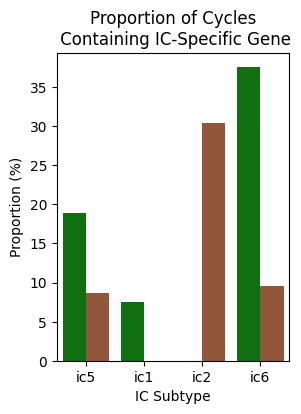

In [11]:
subgroup_target_dict = {"ic5": ["ERBB2"], "ic1": ["RPS6KB1"], "ic2": ["CCND1"], "ic6": ["FGFR1", "ZNF703"]}

plot_data = []

for subgroup, target_genes in subgroup_target_dict.items():
    
    group_df = merged_df[merged_df["ENiClust"] == subgroup]
    group_df["Contains_Gene"] = group_df["Cycle Genes List"].apply(lambda genes: any(gene in genes for gene in target_genes))
    group_df['Confidence_Group'] = group_df['Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})
    
    grouped = group_df.groupby(['Confidence_Group'])['Contains_Gene'].mean().reset_index()
    
    for _, row in grouped.iterrows():
        plot_data.append({
            'Eniclust': subgroup,
            'Confidence': row['Confidence_Group'],
            'Proportion': row['Contains_Gene'] * 100,  # Convert to percentage
            'Target_Gene': target_genes
        })

plot_df = pd.DataFrame(plot_data)

confidence_order = ['high', 'medium/low']
confidence_colors = {
    "high": "green",
    "medium/low": "sienna"
}

plt.figure(figsize=(3, 4))

sns.barplot(data=plot_df, x='Eniclust', y='Proportion', hue='Confidence', dodge=True, hue_order=confidence_order, palette=confidence_colors)

plt.xlabel('IC Subtype')
plt.ylabel('Proportion (%)')
plt.title('Proportion of Cycles\n Containing IC-Specific Gene')
plt.legend().remove()

plt.show()